# Week 1 — Random-Search Baseline: Function_07

**Objective:** establish a naive random-search baseline for this black-box,
maximisation-only function, ahead of Bayesian optimisation in later weeks.

This notebook:
1. Loads the two authorised data files for this function
   (`initial_inputs.npy`, `initial_outputs.npy`).
2. Validates the data (shapes, dtypes, dimensionality, NaN/Inf, duplicates,
   bounds compliance).
3. Reports summary statistics and the best observation so far.
4. Produces exploratory plots appropriate to the input dimensionality
   (6-dimensional inputs, so no single plot forces all input dimensions
   into one chart for functions with more than 2 dimensions).
5. Generates exactly **one** new, reproducible random query using
   `numpy.random.default_rng(seed=49)`, with `seed = 42 + function_number`
   (function_number = 7).
6. Formats that query into the official submission string.

**Data-use / leakage note:** only this function's own `02_Data/` files are
used. No later week, no `04_Results`, and no external source-project data is
read anywhere in this notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## 1. Load data

Loading only the two authorised files for this function from `../02_Data/`.

In [2]:
inputs = np.load("../02_Data/initial_inputs.npy")
outputs = np.load("../02_Data/initial_outputs.npy")

print("inputs shape :", inputs.shape)
print("outputs shape:", outputs.shape)
print("inputs dtype :", inputs.dtype)
print("outputs dtype:", outputs.dtype)
assert inputs.dtype == np.float64, "inputs dtype is not float64"
assert outputs.dtype == np.float64, "outputs dtype is not float64"


inputs shape : (30, 6)
outputs shape: (30,)
inputs dtype : float64
outputs dtype: float64


## 2. Data validation

Computed checks (not assumed): shape/dtype consistency, dimensionality,
NaN/Inf counts, duplicate input rows, and bounds compliance against the
officially confirmed course-wide bound `[0.000000, 0.999999]` (i.e. each
coordinate `>= 0` and strictly `< 1`), per
`Week_01/PRE_MODELLING_VERIFICATION.md`.

In [3]:
n_obs, d_in = inputs.shape
assert outputs.shape == (n_obs,), "outputs shape does not match number of input rows"

print("Number of observations (n):", n_obs)
print("Input dimensionality (d):  ", d_in)
print("Expected dimensionality:   ", 6)
assert d_in == 6, "Input dimensionality does not match the expected value for this function"

nan_inputs = int(np.isnan(inputs).sum())
inf_inputs = int(np.isinf(inputs).sum())
nan_outputs = int(np.isnan(outputs).sum())
inf_outputs = int(np.isinf(outputs).sum())

print("NaN count in inputs :", nan_inputs)
print("Inf count in inputs :", inf_inputs)
print("NaN count in outputs:", nan_outputs)
print("Inf count in outputs:", inf_outputs)

rounded_inputs = np.round(inputs, 6)
unique_rows = np.unique(rounded_inputs, axis=0)
n_duplicates = n_obs - unique_rows.shape[0]
print("Number of duplicate input rows (after rounding to 6 dp):", n_duplicates)

lower_ok = bool(np.all(inputs >= 0.0))
upper_ok = bool(np.all(inputs < 1.0))
min_val = float(inputs.min())
max_val = float(inputs.max())

print("All inputs >= 0.0  :", lower_ok)
print("All inputs <  1.0  :", upper_ok)
print("Observed input min :", min_val)
print("Observed input max :", max_val)
print("Bounds compliant [0.000000, 0.999999]:", lower_ok and upper_ok)


Number of observations (n): 30
Input dimensionality (d):   6
Expected dimensionality:    6
NaN count in inputs : 0
Inf count in inputs : 0
NaN count in outputs: 0
Inf count in outputs: 0
Number of duplicate input rows (after rounding to 6 dp): 0
All inputs >= 0.0  : True
All inputs <  1.0  : True
Observed input min : 0.0036345648296357558
Observed input max : 0.9986546964586872
Bounds compliant [0.000000, 0.999999]: True


## 3. Summary statistics and best observation

Since this is a **maximisation** problem, "best" is defined as the row with
the maximum recorded output value.

In [4]:
out_min = float(outputs.min())
out_max = float(outputs.max())
best_idx = int(np.argmax(outputs))
best_input = inputs[best_idx]
best_output = outputs[best_idx]

print("Output min:", out_min)
print("Output max:", out_max)
print("Output range (max - min):", out_max - out_min)
print()
print("Best observed row index:", best_idx)
print("Best observed input vector:", best_input)
print("Best observed output value:", best_output)


Output min: 0.0027014650245082332
Output max: 1.3649683044991994
Output range (max - min): 1.362266839474691

Best observed row index: 6
Best observed input vector: [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
Best observed output value: 1.3649683044991994


## 4. Exploratory plots

### 4a. Per-feature scatter plots (each input dimension vs. output)

One subplot per input dimension (6 subplots total), each plotting a single
input coordinate against the output. This avoids forcing more than 2
dimensions onto any one chart.

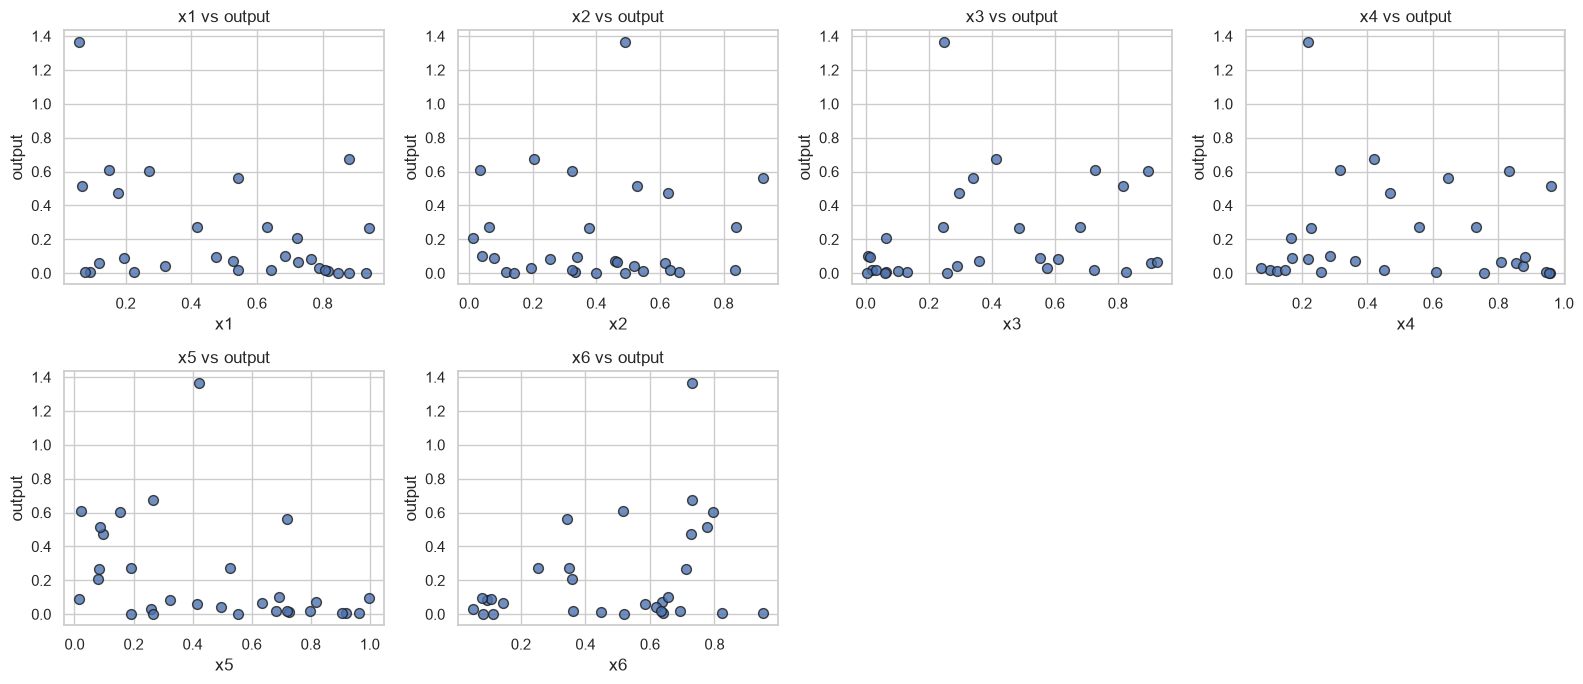

In [5]:
d_in = inputs.shape[1]
ncols = min(d_in, 4)
nrows = int(np.ceil(d_in / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), squeeze=False)

for i in range(d_in):
    r, c = divmod(i, ncols)
    ax = axes[r][c]
    ax.scatter(inputs[:, i], outputs, s=50, edgecolor="k", alpha=0.8)
    ax.set_xlabel(f"x{i+1}")
    ax.set_ylabel("output")
    ax.set_title(f"x{i+1} vs output")

# Hide any unused subplot axes
for j in range(d_in, nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r][c].axis("off")

plt.tight_layout()
plt.show()


### 4b. Distribution of observed output values

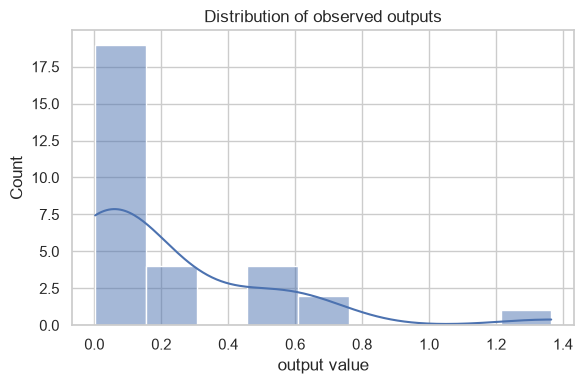

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(outputs, kde=True, ax=ax)
ax.set_xlabel("output value")
ax.set_title("Distribution of observed outputs")
plt.tight_layout()
plt.show()


## 5. Random query generation

Seed policy (fixed for reproducibility): `seed = 42 + function_number`. For
Function_07 (function_number = 7), `seed = 49`.

A single `numpy.random.default_rng` instance is created once and **reused**
(never reseeded) for every draw. A candidate vector of length 6 is drawn
with `rng.random(6)` (uniform on `[0, 1)`) and rounded to six decimal
places. If any rounded coordinate is `>= 1.0`, or the rounded vector exactly
matches an existing (rounded) row of `initial_inputs.npy`, the next vector is
drawn from the **same** generator instance and re-checked, looping until a
valid, unique, in-bounds query is found. The number of draws taken is
recorded below.

In [7]:
seed = 42 + 7
rng = np.random.default_rng(seed)
d = 6

existing_rounded = set(map(tuple, np.round(inputs, 6).tolist()))

attempts = 0
while True:
    candidate = rng.random(d)
    attempts += 1
    rounded = np.round(candidate, 6)

    # Note: rng.random() only ever draws values in [0, 1), so a rounded
    # coordinate can never be negative; the `< 0.0` check below is a
    # defensive, currently-unreachable belt-and-braces guard, not dead logic
    # to be relied upon in place of the reachable `>= 1.0` check.
    out_of_bounds = bool(np.any(rounded >= 1.0)) or bool(np.any(rounded < 0.0))
    is_duplicate = tuple(rounded.tolist()) in existing_rounded

    if out_of_bounds or is_duplicate:
        continue
    break

print("Seed used:", seed)
print("Number of draws needed:", attempts)
print("Out-of-bounds on final draw:", out_of_bounds)
print("Duplicate on final draw:", is_duplicate)
print("Final query vector (rounded to 6 dp):", rounded)


Seed used: 49
Number of draws needed: 1
Out-of-bounds on final draw: False
Duplicate on final draw: False
Final query vector (rounded to 6 dp): [0.362854 0.593217 0.39195  0.623699 0.655815 0.013586]


## 6. Official submission string

Each coordinate formatted to exactly six decimal places, joined with
hyphens, no spaces, no brackets, no commas.

In [8]:
query_string = "-".join(f"{v:.6f}" for v in rounded)
print(query_string)


0.362854-0.593217-0.391950-0.623699-0.655815-0.013586


In [9]:
query_path = "../03_Queries/week_01_query.txt"
with open(query_path, "w") as f:
    f.write(query_string + "\n")
print(f"Query written to {query_path}")


Query written to ../03_Queries/week_01_query.txt


## 7. Notes

- This notebook does **not** write anything to `04_Results`.
- This notebook does **not** fabricate or print any output value for the new
  query above — only the input query itself was generated. The true output
  for this new query does not yet exist and must be obtained by an actual
  black-box submission (outside the scope of this notebook).
- The query string printed in Section 6 is saved verbatim (single line, no
  extra characters) to `../03_Queries/week_01_query.txt`.
- Random-search baseline limitations (see also `Week_01/WEEK_01_METHOD.md`):
  this is a single naive uniform-random draw, exploiting no observed
  structure and modelling no uncertainty; it exists purely as a comparison
  point for Bayesian optimisation introduced in later weeks.
